# ESM features + CNN features → Hybrid classifier → compare with separate models

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [2]:
df = pd.read_csv("../dataset/protein_balanced.csv")

df_hybrid = df.groupby("label").sample(n=5000, random_state=42)

df_hybrid["label"].value_counts()

label
binding      5000
enzyme       5000
transport    5000
Name: count, dtype: int64

In [16]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY"
aa_to_int = {aa: i+1 for i, aa in enumerate(amino_acids)}

MAX_LEN = 300

def encode_sequence(seq):
    seq = seq.upper()
    encoded = [aa_to_int.get(aa, 0) for aa in seq[:MAX_LEN]]
    encoded += [0] * (MAX_LEN - len(encoded))
    return encoded[:MAX_LEN]

In [17]:
X_cnn = np.array([encode_sequence(seq) for seq in df_hybrid["sequence"]])

label_encoder = LabelEncoder()
y_labels = label_encoder.fit_transform(df_hybrid["label"])

print(X_cnn.shape)
print(y_labels.shape)
print(label_encoder.classes_)

(15000, 300)
(15000,)
['binding' 'enzyme' 'transport']


In [18]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, vocab_size=21, embed_dim=128, num_classes=3):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.conv1 = nn.Conv1d(embed_dim, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(128)

        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(256)

        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(0.4)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x, return_features=False):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))

        x = self.pool(x).squeeze(-1)

        features = torch.relu(self.fc1(x))
        output = self.fc2(self.dropout(features))

        if return_features:
            return features

        return output

In [19]:
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = torch.tensor(X_cnn, dtype=torch.long)
y_tensor = torch.tensor(y_labels, dtype=torch.long)

all_dataset = TensorDataset(X_tensor, y_tensor)
all_loader = DataLoader(all_dataset, batch_size=64, shuffle=False)

In [20]:
model_cnn = CNNFeatureExtractor().to(device)

In [22]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn,
    y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

class ProteinDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ProteinDataset(X_train_cnn, y_train_cnn)
test_dataset = ProteinDataset(X_test_cnn, y_test_cnn)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_cnn = CNNFeatureExtractor().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.0005)

EPOCHS = 15

for epoch in range(EPOCHS):
    model_cnn.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model_cnn(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader):.4f}")

Using device: cpu
Epoch [1/15], Loss: 0.7902
Epoch [2/15], Loss: 0.5237
Epoch [3/15], Loss: 0.3874
Epoch [4/15], Loss: 0.2941
Epoch [5/15], Loss: 0.2148
Epoch [6/15], Loss: 0.1499
Epoch [7/15], Loss: 0.1074
Epoch [8/15], Loss: 0.0734
Epoch [9/15], Loss: 0.0471
Epoch [10/15], Loss: 0.0304
Epoch [11/15], Loss: 0.0313
Epoch [12/15], Loss: 0.0248
Epoch [13/15], Loss: 0.0229
Epoch [14/15], Loss: 0.0192
Epoch [15/15], Loss: 0.0138


In [24]:
model_cnn.eval()

cnn_features = []

with torch.no_grad():
    for batch_X, batch_y in all_loader:

        batch_X = batch_X.to(device)

        features = model_cnn(batch_X, return_features=True)

        cnn_features.append(features.cpu().numpy())

cnn_features = np.vstack(cnn_features)

print(cnn_features.shape)

(15000, 128)


In [30]:
import numpy as np

X_embeddings = np.load("../models/X_embeddings.npy")
y_labels = np.load("../models/y_labels.npy")

print(X_embeddings.shape)
print(y_labels.shape)

(15000, 320)
(15000,)


In [31]:
print(cnn_features.shape)
print(X_embeddings.shape)

(15000, 128)
(15000, 320)


In [32]:
hybrid_features = np.concatenate(
    [X_embeddings, cnn_features],
    axis=1
)

print(hybrid_features.shape)

(15000, 448)


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    hybrid_features,
    y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

hybrid_model = SVC(kernel="linear")

hybrid_model.fit(X_train, y_train)

y_pred = hybrid_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Hybrid Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Hybrid Accuracy: 0.8983333333333333
              precision    recall  f1-score   support

     binding       0.90      0.90      0.90      1000
      enzyme       0.88      0.88      0.88      1000
   transport       0.91      0.92      0.92      1000

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



In [35]:
import joblib

joblib.dump(
    hybrid_model,
    "../models/hybrid_cnn_esm_model.pkl"
)

print("Hybrid model saved successfully!")

Hybrid model saved successfully!


In [36]:
import numpy as np

np.save("../models/hybrid_features.npy", hybrid_features)

print("Hybrid features saved!")

Hybrid features saved!


In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_conf_matrix(y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()

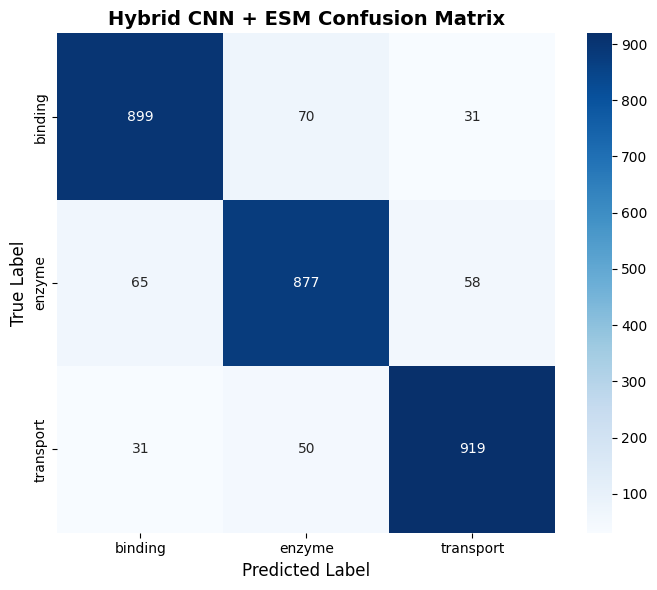

In [40]:
plot_conf_matrix(
    y_test,
    y_pred,
    "Hybrid CNN + ESM Confusion Matrix",
    ["binding", "enzyme", "transport"]
)